In [1]:
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

BASE_URL = "https://www.sandbox.go.kr"
LIST_URL = BASE_URL + "/sandbox.SandboxTaskSlPL"
DETAIL_URL = BASE_URL + "/sandbox.SandboxTaskSl"

Path("data").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)

In [2]:
rows = []

for page in range(1, 113):

    payload = {
        "targetRow": str((page - 1) * 10 + 1),
        "pageNo": str(page),
        "mini_field_cd": "03",
        "exception_type": "",
        "rowCount": "10",
        "sch_text": ""
    }

    r = requests.post(LIST_URL, data=payload, timeout=30)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "html.parser")

    for a in soup.select("a.c-text[onclick*='f_detilView']"):

        match = re.search(
            r"f_detilView\(['\"]?(\d+)",
            a.get("onclick", "")
        )

        if not match:
            continue

    
        # 핵심: a가 아니라 부모 카드 전체
       
        card = a.parent

        # 혹시 한 단계 위에 메타정보가 있으면 계속 확장
        while card and "승인일" not in card.get_text(" ", strip=True):
            card = card.parent

        card_text = (
            card.get_text(" ", strip=True)
            if card else ""
        )

        title_el = a.select_one(".c-tit")
        company_el = a.select_one(".sub-txt b")

        title = (
            title_el.get_text(" ", strip=True)
            if title_el else None
        )

        company = (
            company_el.get_text(" ", strip=True)
            if company_el else None
        )

        department_match = re.search(
            r"주관부처\s*:\s*(.*?)\s*(?=분야\s*:)",
            card_text
        )

        field_match = re.search(
            r"분야\s*:\s*(.*?)\s*(?=승인일\s*:)",
            card_text
        )

        date_match = re.search(
            r"승인일\s*:\s*(\d{4}-\d{2}-\d{2})",
            card_text
        )

        rows.append({
            "task_seq": match.group(1),
            "title": title,
            "company": company,
            "department": (
                department_match.group(1).strip()
                if department_match else None
            ),
            "field": (
                field_match.group(1).strip()
                if field_match else None
            ),
            "approval_date": (
                date_match.group(1)
                if date_match else None
            )
        })

    if page % 10 == 0 or page == 112:
        print(f"{page}/112 | {len(rows)}건")

    time.sleep(0.1)


df_list = pd.DataFrame(rows)

df_list["task_seq"] = df_list["task_seq"].astype(str)

df_list = (
    df_list
    .drop_duplicates("task_seq")
    .reset_index(drop=True)
)

df_list["approval_date"] = pd.to_datetime(
    df_list["approval_date"],
    errors="coerce"
)

print("전체:", len(df_list))
print("승인일:", df_list["approval_date"].notna().sum())
print("승인일 누락:", df_list["approval_date"].isna().sum())

display(df_list.head(10))

10/112 | 100건
20/112 | 200건
30/112 | 300건
40/112 | 400건
50/112 | 500건
60/112 | 600건
70/112 | 700건
80/112 | 800건
90/112 | 900건
100/112 | 1000건
110/112 | 1100건
112/112 | 1112건
전체: 1112
승인일: 1112
승인일 누락: 0


,task_seq,title,company,department,field,approval_date
0,2921,방한 외국인 대상 선불전자지급수단 발행 서비스,네이버파이낸셜,금융위원회(혁신금융),혁신금융,2026-07-15
1,2957,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스,아이엠뱅크,금융위원회(혁신금융),혁신금융,2026-07-15
2,2955,공동대출 서비스,카카오뱅크(부산은행),금융위원회(혁신금융),혁신금융,2026-07-15
3,2956,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스,경남은행,금융위원회(혁신금융),혁신금융,2026-07-15
4,2958,토스인증서 기반 페이스페이 간편 실명확인 서비스,비바리퍼블리카,금융위원회(혁신금융),혁신금융,2026-07-15
5,2905,임직원용 지능형 업무지식 챗봇 서비스,삼성화재해상보험,금융위원회(혁신금융),혁신금융,2026-07-01
6,2906,생성형 AI 기반 비즈니스 어시스턴트 서비스,아이엠라이프생명보험,금융위원회(혁신금융),혁신금융,2026-07-01
7,2907,생성형AI기반 대화형 검색 서비스,웰컴저축은행,금융위원회(혁신금융),혁신금융,2026-07-01
8,2908,정보보호 AI 플랫폼(SekAI),카카오뱅크,금융위원회(혁신금융),혁신금융,2026-07-01
9,2887,금융기관보험대리점의 판매비중 규제 개선,서울강서농업협동조합,금융위원회(혁신금융),혁신금융,2026-07-01


In [4]:
# 3. Sentence Embedding
# 목적: 사전 기술분류 없이 Sandbox 전체 의미 구조 탐색
# Corpus = title + company + department + field


from sentence_transformers import SentenceTransformer

# 1. 분석용 DataFrame
df = df_list.copy()

print("사용 컬럼:", df.columns.tolist())


# 2. Corpus 생성
# 현재 수집된 실제 컬럼만 사용
df["sandbox_text"] = (
    df["title"].fillna("").astype(str)
    + " "
    + df["company"].fillna("").astype(str)
    + " "
    + df["department"].fillna("").astype(str)
    + " "
    + df["field"].fillna("").astype(str)
)

# 공백 정리
df["sandbox_text"] = (
    df["sandbox_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("\n===== Corpus =====")
print("전체 문서:", len(df))
print("빈 문서:", (df["sandbox_text"].str.len() == 0).sum())

display(
    df[
        ["task_seq", "title", "company",
         "department", "field", "approval_date", "sandbox_text"]
    ].head()
)


# 3. SentenceTransformer
model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

embeddings = model.encode(
    df["sandbox_text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings = np.asarray(embeddings)


# 4. 검증
print("\n===== Sentence Embedding =====")
print("문서:", len(df))
print("Embedding shape:", embeddings.shape)

assert len(df) == len(embeddings)

print("Embedding 완료")

사용 컬럼: ['task_seq', 'title', 'company', 'department', 'field', 'approval_date']

===== Corpus =====
전체 문서: 1112
빈 문서: 0


,task_seq,title,company,department,field,approval_date,sandbox_text
0,2921,방한 외국인 대상 선불전자지급수단 발행 서비스,네이버파이낸셜,금융위원회(혁신금융),혁신금융,2026-07-15,방한 외국인 대상 선불전자지급수단 발행 서비스 네이버파이낸셜 금융위원회(혁신금융) ...
1,2957,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스,아이엠뱅크,금융위원회(혁신금융),혁신금융,2026-07-15,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스 아이엠뱅...
2,2955,공동대출 서비스,카카오뱅크(부산은행),금융위원회(혁신금융),혁신금융,2026-07-15,공동대출 서비스 카카오뱅크(부산은행) 금융위원회(혁신금융) 혁신금융
3,2956,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스,경남은행,금융위원회(혁신금융),혁신금융,2026-07-15,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스 경남은행...
4,2958,토스인증서 기반 페이스페이 간편 실명확인 서비스,비바리퍼블리카,금융위원회(혁신금융),혁신금융,2026-07-15,토스인증서 기반 페이스페이 간편 실명확인 서비스 비바리퍼블리카 금융위원회(혁신금융)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]


===== Sentence Embedding =====
문서: 1112
Embedding shape: (1112, 384)
Embedding 완료


In [5]:
# 02. Optimal K 탐색


k_range = range(2, 16)

inertias = []
silhouette_scores = []

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(embeddings)

    inertias.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(embeddings, labels)
    )

    print(
        f"K={k:2d} | "
        f"Inertia={km.inertia_:,.2f} | "
        f"Silhouette={silhouette_scores[-1]:.4f}"
    )

K= 2 | Inertia=347.20 | Silhouette=0.1660
K= 3 | Inertia=312.72 | Silhouette=0.1392
K= 4 | Inertia=284.90 | Silhouette=0.1681
K= 5 | Inertia=267.83 | Silhouette=0.1842
K= 6 | Inertia=252.34 | Silhouette=0.1752
K= 7 | Inertia=243.90 | Silhouette=0.1721
K= 8 | Inertia=237.32 | Silhouette=0.1522
K= 9 | Inertia=231.22 | Silhouette=0.1499
K=10 | Inertia=226.88 | Silhouette=0.1431
K=11 | Inertia=220.93 | Silhouette=0.1497
K=12 | Inertia=217.67 | Silhouette=0.1379
K=13 | Inertia=213.88 | Silhouette=0.1383
K=14 | Inertia=211.71 | Silhouette=0.1506
K=15 | Inertia=208.81 | Silhouette=0.1068


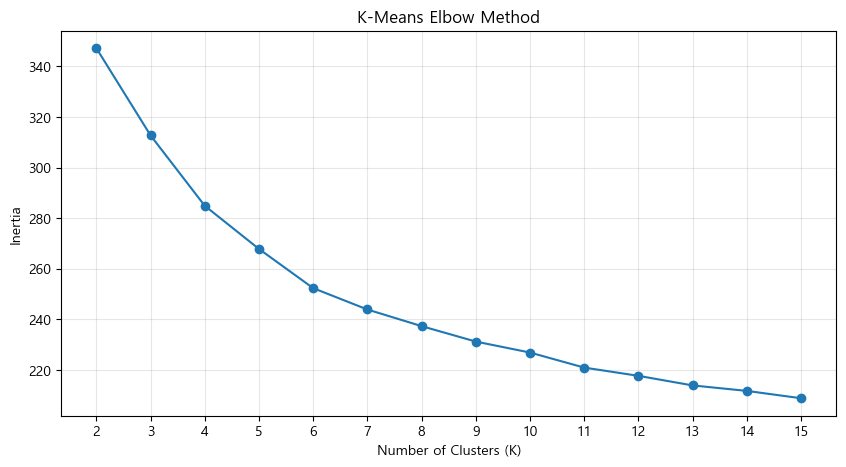

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(
    list(k_range),
    inertias,
    marker="o"
)

plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# 01. 분석 텍스트 정제 → Sentence Embedding 

import re

import numpy as np
from sentence_transformers import SentenceTransformer

df_analysis = df_list.copy()

STOPWORDS = [
    "서비스", "활용", "이용", "기반", "제공",
    "통한", "관련", "업무", "금융", "혁신",
    "시스템", "플랫폼"
]

def clean_title(text):
    text = str(text)

    for word in STOPWORDS:
        text = re.sub(word, " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


df_analysis["analysis_text"] = (
    df_analysis["title"]
    .fillna("")
    .apply(clean_title)
)

display(
    df_analysis[
        ["title", "analysis_text"]
    ].head(20)
)


model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

embeddings = model.encode(
    df_analysis["analysis_text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings = np.asarray(embeddings)

print("Embedding:", embeddings.shape)

,title,analysis_text
0,방한 외국인 대상 선불전자지급수단 발행 서비스,방한 외국인 대상 선불전자지급수단 발행
1,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스,한국은행 디지털화폐(CBDC) 내 예금 토큰 지급·결제
2,공동대출 서비스,공동대출
3,한국은행 디지털화폐(CBDC) 시스템 내 예금 토큰 기반 지급·결제 서비스,한국은행 디지털화폐(CBDC) 내 예금 토큰 지급·결제
4,토스인증서 기반 페이스페이 간편 실명확인 서비스,토스인증서 페이스페이 간편 실명확인
5,임직원용 지능형 업무지식 챗봇 서비스,임직원용 지능형 지식 챗봇
6,생성형 AI 기반 비즈니스 어시스턴트 서비스,생성형 AI 비즈니스 어시스턴트
7,생성형AI기반 대화형 검색 서비스,생성형AI 대화형 검색
8,정보보호 AI 플랫폼(SekAI),정보보호 AI (SekAI)
9,금융기관보험대리점의 판매비중 규제 개선,기관보험대리점의 판매비중 규제 개선


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

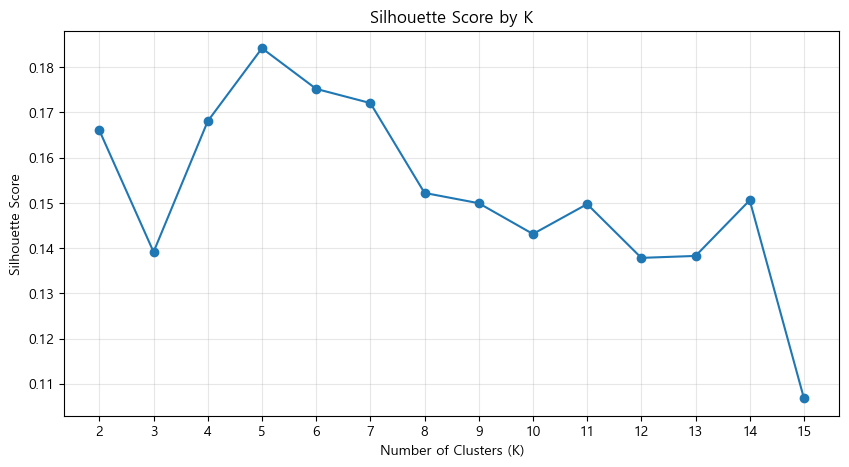

Silhouette 기준 Best K: 5


In [7]:
plt.figure(figsize=(10, 5))

plt.plot(
    list(k_range),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)

plt.show()

best_k = list(k_range)[
    np.argmax(silhouette_scores)
]

print("Silhouette 기준 Best K:", best_k)

In [9]:
FINAL_K = 11

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

df_analysis["cluster"] = kmeans.fit_predict(
    embeddings
)

In [10]:
# Cluster별 핵심 키워드


cluster_summary = []

for cluster_id in sorted(df_analysis["cluster"].unique()):

    temp = df_analysis[
        df_analysis["cluster"] == cluster_id
    ]

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=5000
    )

    X = vectorizer.fit_transform(
        temp["analysis_text"]
    )

    terms = np.array(
        vectorizer.get_feature_names_out()
    )

    scores = np.asarray(
        X.mean(axis=0)
    ).ravel()

    top_idx = scores.argsort()[::-1][:15]

    keywords = terms[top_idx].tolist()

    cluster_summary.append({
        "cluster": cluster_id,
        "count": len(temp),
        "keywords": ", ".join(keywords[:10]),
        "auto_label": " / ".join(keywords[:3])
    })


cluster_summary = (
    pd.DataFrame(cluster_summary)
    .sort_values("count", ascending=False)
)

cluster_summary["ratio"] = (
    cluster_summary["count"]
    / len(df_analysis)
    * 100
).round(1)

display(cluster_summary)

,cluster,count,keywords,auto_label,ratio
2,2,174,"ai, 생성형, 생성형 ai, ai를, 생성형 ai를, azure, 위한, 분석, ...",ai / 생성형 / 생성형 ai,15.6
0,0,148,"상장거래, 상장클래스, 상장클래스 신설을, 신설을, 신설을 상장거래, 일반, 공모펀...",상장거래 / 상장클래스 / 상장클래스 신설을,13.3
4,4,135,"소프트웨어 saas, 소프트웨어, 클라우드를, saas 내부망, 클라우드를 소프트웨...",소프트웨어 saas / 소프트웨어 / 클라우드를,12.1
5,5,134,"모바일, 비교, 대출, 위한, 카드, 추천, 개인, 부동산, 빅데이터, 은행",모바일 / 비교 / 대출,12.1
7,7,127,"내부망, 위한, 클라우드, 데이터, 대화형, 분석, 생성형ai를, 클라우드를, 고객...",내부망 / 위한 / 클라우드,11.4
6,6,89,"기관보험대리점의, 기관보험대리점의 판매비중, 판매비중 규제, 판매비중, 규제, 개선...",기관보험대리점의 / 기관보험대리점의 판매비중 / 판매비중 규제,8.0
10,10,84,"m365, copilot, m365 copilot, 내부망, 소프트웨어, 클라우드를...",m365 / copilot / m365 copilot,7.6
3,3,63,"소수단위, 소수단위 거래, 거래, 국내주식, 국내주식 소수단위, 해외주식, 해외주식...",소수단위 / 소수단위 거래 / 거래,5.7
8,8,62,"온라인투자연계, 투자자로 참여하는, 저축은행이, 신용, 신용 연계대출, 투자자로, ...",온라인투자연계 / 투자자로 참여하는 / 저축은행이,5.6
1,1,58,"saas, ms, 내부망에서 ms, 내부망에서, 보안, 보안 saas, ms 보안,...",saas / ms / 내부망에서 ms,5.2


cluster,0,1,2,3,4,5,6,7,8,9,10
year,,,,,,,,,,,
2019,6,0,4,4,0,40,8,14,0,1,0
2020,8,0,1,2,0,23,12,9,2,1,0
2021,10,0,0,21,0,9,0,5,0,5,0
2022,6,0,0,30,0,8,0,0,0,8,0
2023,1,0,1,0,16,6,11,5,0,16,0
2024,60,2,29,0,49,19,0,13,29,6,0
2025,47,56,103,4,70,21,44,67,1,1,84
2026,10,0,36,2,0,8,14,14,30,0,0


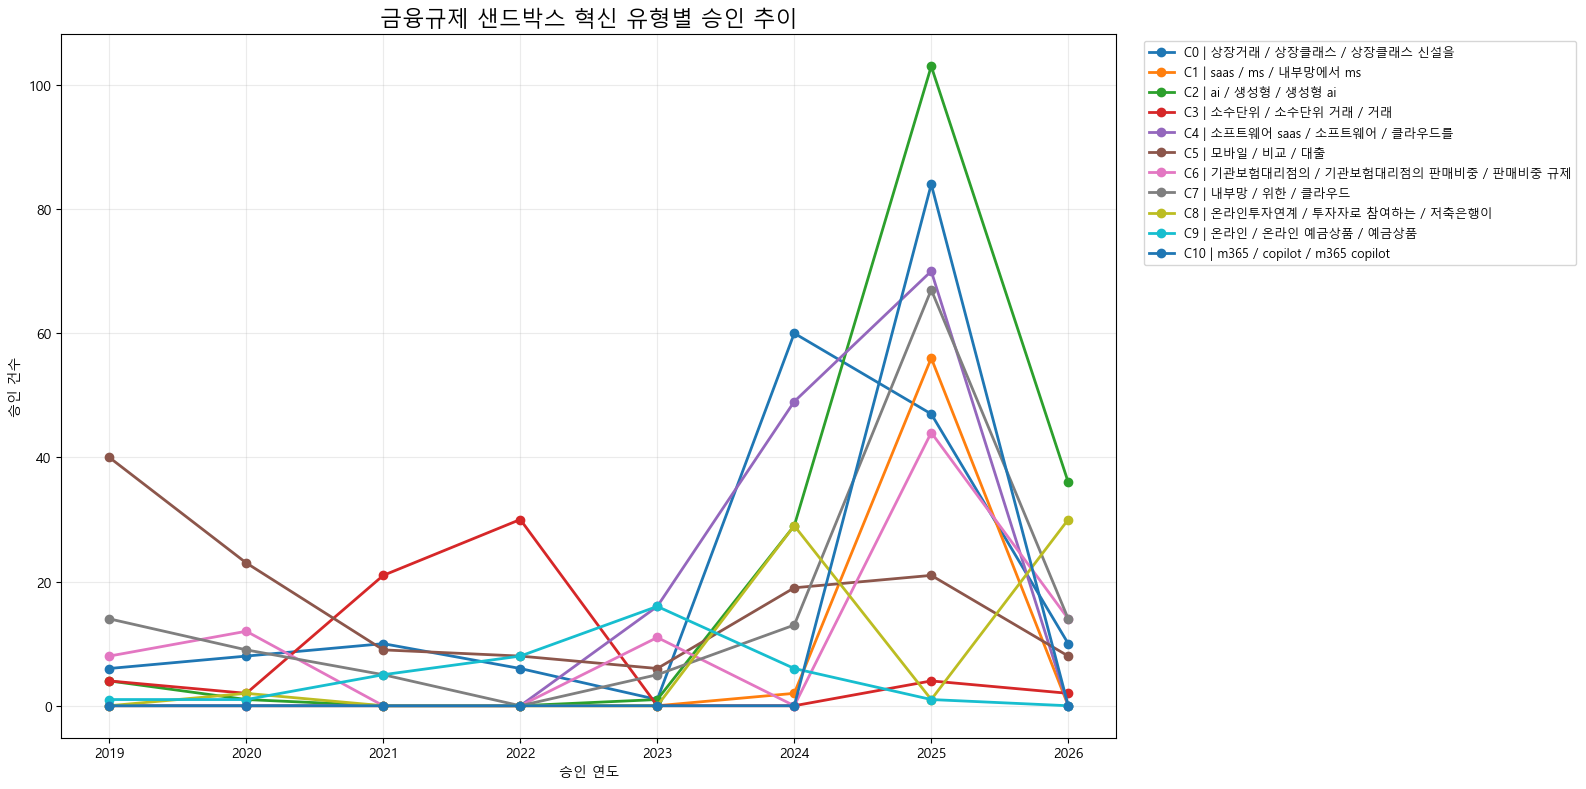

In [11]:
# 04. Cluster 승인일 기준 시계열 분석

# 날짜 확인
df_analysis["approval_date"] = pd.to_datetime(
    df_analysis["approval_date"],
    errors="coerce"
)

df_analysis["year"] = df_analysis["approval_date"].dt.year


# 1. 연도 × Cluster 건수

year_cluster = (
    df_analysis
    .groupby(["year", "cluster"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

display(year_cluster)


# 2. Cluster 번호 → 현재 자동 라벨
label_map = (
    cluster_summary
    .set_index("cluster")["auto_label"]
    .to_dict()
)


# ------------------------------------------------------------
# 3. 시계열 Line Chart
# ------------------------------------------------------------

plt.figure(figsize=(16, 8))

for cluster_id in year_cluster.columns:

    plt.plot(
        year_cluster.index,
        year_cluster[cluster_id],
        marker="o",
        linewidth=2,
        label=f"C{cluster_id} | {label_map.get(cluster_id, '')}"
    )

plt.title(
    "금융규제 샌드박스 혁신 유형별 승인 추이",
    fontsize=16
)

plt.xlabel("승인 연도")
plt.ylabel("승인 건수")

plt.xticks(year_cluster.index)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()

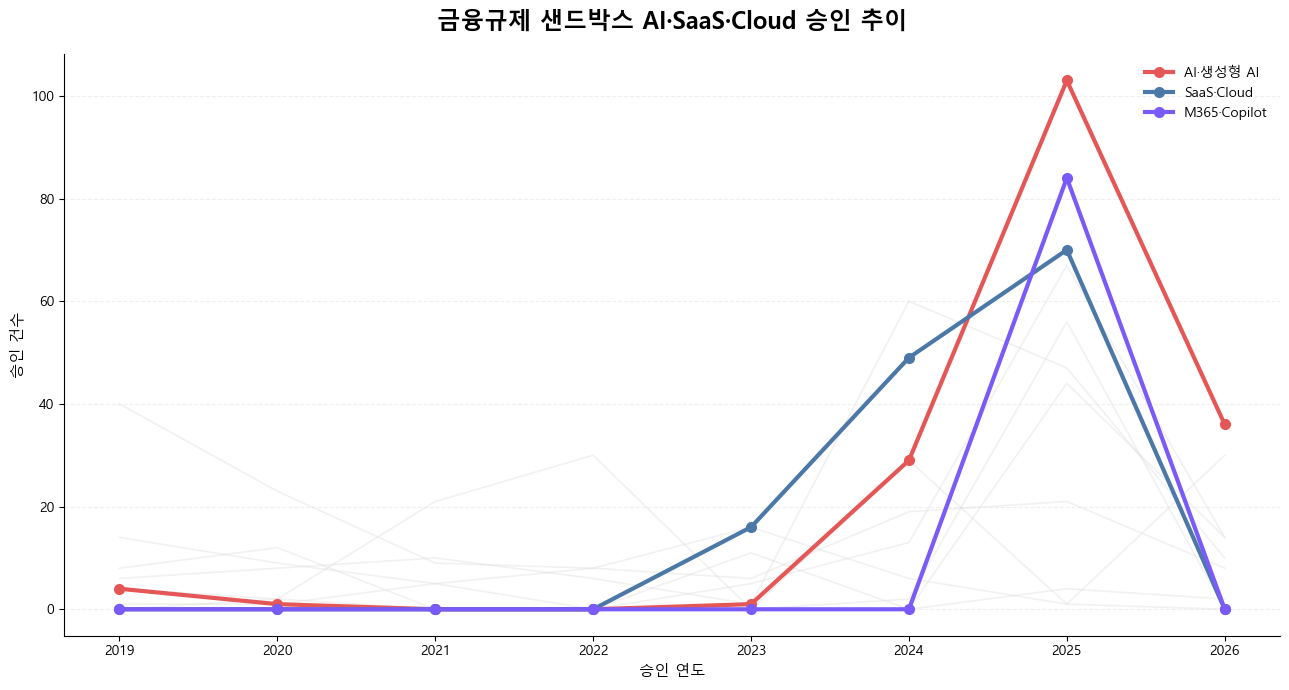

In [15]:
# 04. Cluster 승인일 기준 시계열 분석

df_analysis["approval_date"] = pd.to_datetime(
    df_analysis["approval_date"],
    errors="coerce"
)

df_analysis["year"] = df_analysis["approval_date"].dt.year

# 연도 × Cluster 건수
year_cluster = (
    df_analysis
    .groupby(["year", "cluster"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 핵심 기술 Cluster
highlight = {
    2: {
        "label": "AI·생성형 AI",
        "color": "#E45756"
    },
    4: {
        "label": "SaaS·Cloud",
        "color": "#4C78A8"
    },
    10: {
        "label": "M365·Copilot",
        "color": "#7A5AF8"
    }
}

plt.figure(figsize=(13, 7))

# 나머지 Cluster는 배경 흐름으로만 표시
for cluster_id in year_cluster.columns:
    if cluster_id not in highlight:
        plt.plot(
            year_cluster.index,
            year_cluster[cluster_id],
            color="#D9D9D9",
            linewidth=1.2,
            alpha=0.35
        )

# 핵심 Cluster 강조
for cluster_id, info in highlight.items():

    if cluster_id in year_cluster.columns:
        plt.plot(
            year_cluster.index,
            year_cluster[cluster_id],
            marker="o",
            markersize=7,
            linewidth=3,
            color=info["color"],
            label=info["label"]
        )

plt.title(
    "금융규제 샌드박스 AI·SaaS·Cloud 승인 추이",
    fontsize=17,
    fontweight="bold",
    pad=18
)

plt.xlabel("승인 연도", fontsize=11)
plt.ylabel("승인 건수", fontsize=11)

plt.xticks(year_cluster.index)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

plt.legend(
    frameon=False,
    fontsize=10
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()